# Student Performance Analysis

This project analyzes factors affecting student exam performance using a dataset of 6642 students.
The dataset contains 20 features including study habits, attendance, sleep hours, family income,
parental involvement, and school type across both public and private schools.

**Goal:** Analyze students score and identify which factors affect students marks the most,


**Dataset:** Student Performance Factors from Kaggle

# Questions

1. What is the average Exam_Score per Motivation_Level?
2. Which Gender has a higher average Exam_Score?
3. Do students with Internet_Access score higher?
4. What is the average Hours_Studied per Family_Income?
5. How many students have Learning_Disabilities and what is their average score?
6. Public schools vs private schools distribution and average grades.
7. What is the distribution of the exam marks?
8. Correlation between Hours_Studied, Attendance, Sleep_Hours and Exam_Score.
9. Tutoring_Sessions vs Exam_Score.
10. Does school and parents income affect score?
11. Can "high effort" overcome socioeconomic barriers?
12. Does studying more always lead to a better score?
13. Top 10% students vs bottom 10% students.
14. What's the routine of the students with high attendance?
15. What is the most common motivation level among top scorers (above 85)?

# 1- Understanding data


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('Dirty_StudentPerformanceFactors.csv', )
df.describe()


,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,7647.000000,7647.000000,7647.000000,7647.000000,7647.000000,7647.000000
mean,79.977769,7.017654,75.115470,1.488296,2.969400,67.319733
std,11.580492,1.467880,14.418455,1.223768,1.027788,7.843480
min,60.000000,4.000000,50.000000,0.000000,0.000000,-20.000000
25%,70.000000,6.000000,63.000000,1.000000,2.000000,65.000000
50%,80.000000,7.000000,75.000000,1.000000,3.000000,67.000000
75%,90.000000,8.000000,88.000000,2.000000,4.000000,69.000000
max,100.000000,10.000000,100.000000,8.000000,6.000000,150.000000


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7647 entries, 0 to 7646
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               7629 non-null   str  
 1   Attendance                  7647 non-null   int64
 2   Parental_Involvement        7647 non-null   str  
 3   Access_to_Resources         7647 non-null   str  
 4   Extracurricular_Activities  7647 non-null   str  
 5   Sleep_Hours                 7647 non-null   int64
 6   Previous_Scores             7647 non-null   int64
 7   Motivation_Level            7647 non-null   str  
 8   Internet_Access             7647 non-null   str  
 9   Tutoring_Sessions           7647 non-null   int64
 10  Family_Income               7647 non-null   str  
 11  Teacher_Quality             6573 non-null   str  
 12  School_Type                 7647 non-null   str  
 13  Peer_Influence              7647 non-null   str  
 14  Physical_Activity  

In [3]:
df.head(10)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,LOW,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,150
1,19,64,Low,Medium,No,8,59,LOW,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,150
2,24,98,Medium,Medium,Yes,7,91,MEDIUM,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,150
3,29,89,Low,Medium,Yes,8,98,MEDIUM,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,150
4,19,92,Medium,Medium,Yes,6,65,MEDIUM,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,150
5,19,88,Medium,Medium,Yes,8,89,MEDIUM,Yes,3,Medium,Medium,Public,Positive,3,No,Postgraduate,Near,Male,150
6,29,84,Medium,Low,Yes,7,68,LOW,Yes,1,Low,Medium,Private,Neutral,2,No,High School,Moderate,Male,150
7,25,78,Low,High,Yes,6,50,MEDIUM,Yes,1,High,High,Public,Negative,2,No,High School,Far,Male,150
8,17,94,Medium,High,No,6,80,HIGH,Yes,0,Medium,Low,Private,Neutral,1,No,College,Near,Male,150
9,23,98,Medium,Medium,Yes,8,71,MEDIUM,Yes,0,High,High,Public,Positive,5,No,High School,Moderate,Male,150


# 2- Data preprocessing


## Check data for duplicated and remove them

In [4]:
df.duplicated().sum()

np.int64(696)

In [5]:
df.drop_duplicates(inplace = True)

In [6]:
df.duplicated().sum()

np.int64(0)

## Check Data for missing values





In [7]:
df.isnull().sum()

Hours_Studied                   18
Attendance                       0
Parental_Involvement             0
Access_to_Resources              0
Extracurricular_Activities       0
Sleep_Hours                      0
Previous_Scores                  0
Motivation_Level                 0
Internet_Access                  0
Tutoring_Sessions                0
Family_Income                    0
Teacher_Quality               1019
School_Type                      0
Peer_Influence                   0
Physical_Activity                0
Learning_Disabilities            0
Parental_Education_Level        97
Distance_from_Home              72
Gender                           0
Exam_Score                       0
dtype: int64


Fixing Data type of hours_studied column



We need to deal with these NaN values before converting them to integers

so we will convert them from string to a float (because floats can store NaN)

then compute the mean in missin values and conver

In [8]:
df['Hours_Studied'] = pd.to_numeric(df['Hours_Studied'], errors='coerce')

In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 6951 entries, 0 to 7645
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6901 non-null   float64
 1   Attendance                  6951 non-null   int64  
 2   Parental_Involvement        6951 non-null   str    
 3   Access_to_Resources         6951 non-null   str    
 4   Extracurricular_Activities  6951 non-null   str    
 5   Sleep_Hours                 6951 non-null   int64  
 6   Previous_Scores             6951 non-null   int64  
 7   Motivation_Level            6951 non-null   str    
 8   Internet_Access             6951 non-null   str    
 9   Tutoring_Sessions           6951 non-null   int64  
 10  Family_Income               6951 non-null   str    
 11  Teacher_Quality             5932 non-null   str    
 12  School_Type                 6951 non-null   str    
 13  Peer_Influence              6951 non-null   str  

In [10]:
df['Hours_Studied'] = df['Hours_Studied'].fillna(df['Hours_Studied'].median())

In [11]:
df['Hours_Studied'] = df['Hours_Studied'].astype(int) 

In [12]:
df.info()

<class 'pandas.DataFrame'>
Index: 6951 entries, 0 to 7645
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6951 non-null   int64
 1   Attendance                  6951 non-null   int64
 2   Parental_Involvement        6951 non-null   str  
 3   Access_to_Resources         6951 non-null   str  
 4   Extracurricular_Activities  6951 non-null   str  
 5   Sleep_Hours                 6951 non-null   int64
 6   Previous_Scores             6951 non-null   int64
 7   Motivation_Level            6951 non-null   str  
 8   Internet_Access             6951 non-null   str  
 9   Tutoring_Sessions           6951 non-null   int64
 10  Family_Income               6951 non-null   str  
 11  Teacher_Quality             5932 non-null   str  
 12  School_Type                 6951 non-null   str  
 13  Peer_Influence              6951 non-null   str  
 14  Physical_Activity       

## Handle outliers

In [13]:
df.describe()


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6951.000000,6951.000000,6951.000000,6951.000000,6951.000000,6951.000000,6951.000000
mean,19.972090,79.967199,7.023018,75.072508,1.490001,2.969213,67.347576
std,5.966725,11.548437,1.471275,14.408328,1.230257,1.029732,8.149169
min,1.000000,60.000000,4.000000,50.000000,0.000000,0.000000,-20.000000
25%,16.000000,70.000000,6.000000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.000000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.000000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.000000,100.000000,8.000000,6.000000,150.000000


In [14]:
from datasist.structdata import detect_outliers
detect_outliers(df, 0, ['Exam_Score', 'Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores'])

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 94,
 106,
 113,
 209,
 217,
 404,
 529,
 558,
 560,
 637,
 668,
 770,
 836,
 919,
 1099,
 1101,
 1107,
 1109,
 1165,
 1210,
 1351,
 1387,
 1418,
 1525,
 1607,
 1615,
 1750,
 1844,
 1863,
 1957,
 2035,
 2076,
 2178,
 2265,
 2292,
 2411,
 2421,
 2425,
 2513,
 2533,
 2542,
 2544,
 2556,
 2595,
 2687,
 2880,
 2904,
 2947,
 2954,
 3124,
 3141,
 3212,
 3241,
 3357,
 3364,
 3418,
 3457,
 3493,
 3523,
 3543,
 3579,
 3593,
 3602,
 3716,
 3815,
 3924,
 3932,
 4033,
 4091,
 4192,
 4247,
 4254,
 4297,
 4355,
 4405,
 4425,
 4458,
 4531,
 4583,
 4635,
 4639,
 4666,
 4697,
 4728,
 4774,
 4779,
 5017,
 5125,
 5198,
 5507,
 5519,
 5719,
 5790,
 5907,
 5966,
 5989,
 6000,
 6040,
 6202,
 6347,
 6393,
 6431,
 6522,
 6566,
 6635,
 7000,
 7560,
 262,
 478,
 1061,
 1539,


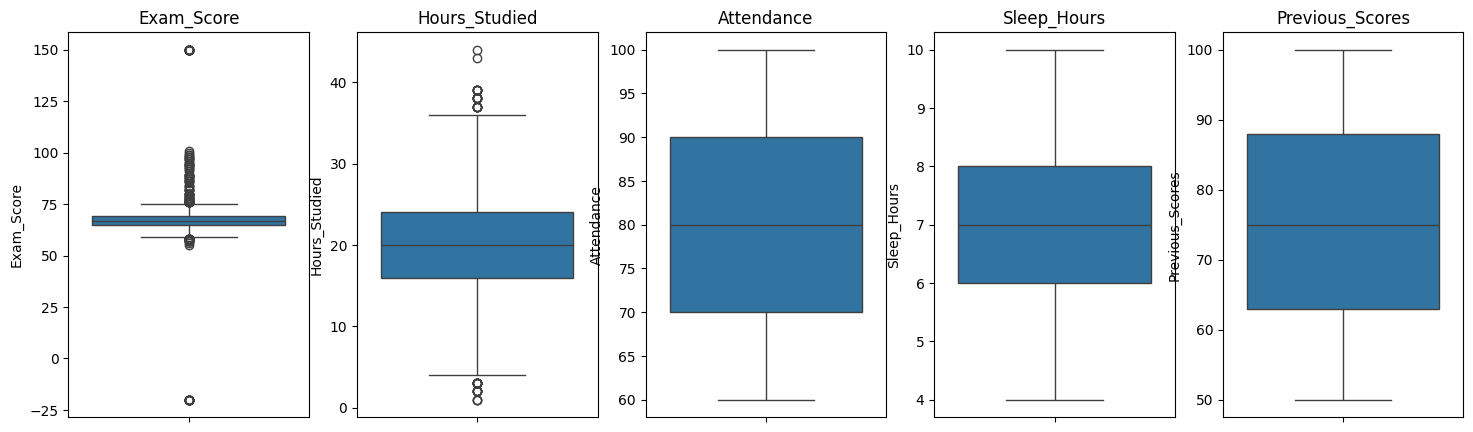

In [15]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
cols = ['Exam_Score', 'Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores']

for i, col in enumerate(cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)


plt.show()

Exam_Score and Hours_Studied columns  has some extreme values

In [16]:
def fix_outliers(df, col, min_val, max_val):
    mean = int(df.loc[(df[col] >= min_val) & (df[col] <= max_val), col].mean())
    df.loc[df[col] > max_val, col] = mean
    df.loc[df[col] < min_val, col] = mean
    return df

df = fix_outliers(df, 'Exam_Score', 0, 100)
df = fix_outliers(df, 'Hours_Studied', 1, 44)



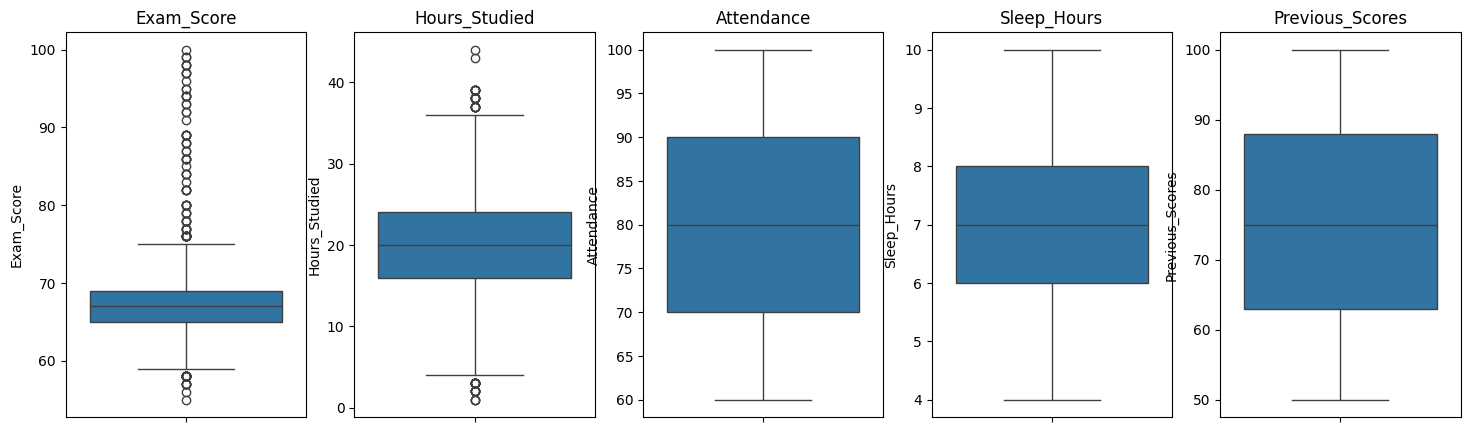

In [17]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
cols = ['Exam_Score', 'Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores']

for i, col in enumerate(cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)


plt.show()

## Handle inconsistent formatting in motivation_level column


In [18]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,LOW,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,LOW,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,67
2,24,98,Medium,Medium,Yes,7,91,MEDIUM,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,67
3,29,89,Low,Medium,Yes,8,98,MEDIUM,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,67
4,19,92,Medium,Medium,Yes,6,65,MEDIUM,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,67


check if there are other columns with incorrect formatting

In [19]:
for col in df.select_dtypes(include='str').columns:
    display(df[col].value_counts())

Parental_Involvement
Medium    3554
High      1996
Low       1401
Name: count, dtype: int64

Access_to_Resources
Medium    3483
High      2093
Low       1375
Name: count, dtype: int64

Extracurricular_Activities
Yes    4140
No     2811
Name: count, dtype: int64

Motivation_Level
Medium        3405
Low           1974
High          1372
MEDIUM          57
  Medium        52
LOW             29
  Low           28
  High          20
HIGH            14
Name: count, dtype: int64

Internet_Access
Yes    6431
No      520
Name: count, dtype: int64

...

Peer_Influence
Positive    2754
Neutral     2738
Negative    1459
Name: count, dtype: int64

Learning_Disabilities
No     6221
Yes     730
Name: count, dtype: int64

Parental_Education_Level
High School     3390
College         2092
Postgraduate    1372
Name: count, dtype: int64

Distance_from_Home
Near        4085
Moderate    2098
Far          696
Name: count, dtype: int64

Gender
Male      4014
Female    2937
Name: count, dtype: int64

In [20]:
def fix_formatting(df, cols):
    for col in cols:
        df[col] = df[col].str.strip().str.title()
    return df

df = fix_formatting(df, ['Motivation_Level'])

In [21]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,67
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,67
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,67
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,67


In [22]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6951.000000,6951.000000,6951.000000,6951.000000,6951.000000,6951.000000,6951.000000
mean,19.972090,79.967199,7.023018,75.072508,1.490001,2.969213,67.234786
std,5.966725,11.548437,1.471275,14.408328,1.230257,1.029732,3.845820
min,1.000000,60.000000,4.000000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.000000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.000000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.000000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.000000,100.000000,8.000000,6.000000,100.000000


In [23]:
df.info()

<class 'pandas.DataFrame'>
Index: 6951 entries, 0 to 7645
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6951 non-null   int64
 1   Attendance                  6951 non-null   int64
 2   Parental_Involvement        6951 non-null   str  
 3   Access_to_Resources         6951 non-null   str  
 4   Extracurricular_Activities  6951 non-null   str  
 5   Sleep_Hours                 6951 non-null   int64
 6   Previous_Scores             6951 non-null   int64
 7   Motivation_Level            6951 non-null   str  
 8   Internet_Access             6951 non-null   str  
 9   Tutoring_Sessions           6951 non-null   int64
 10  Family_Income               6951 non-null   str  
 11  Teacher_Quality             5932 non-null   str  
 12  School_Type                 6951 non-null   str  
 13  Peer_Influence              6951 non-null   str  
 14  Physical_Activity       

In [24]:
for col in ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']:
    df[col] = df[col].fillna(df[col].mode()[0])



In [25]:
df.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

# Questions

## 1- What is the average Exam_Score per Motivation_Level?

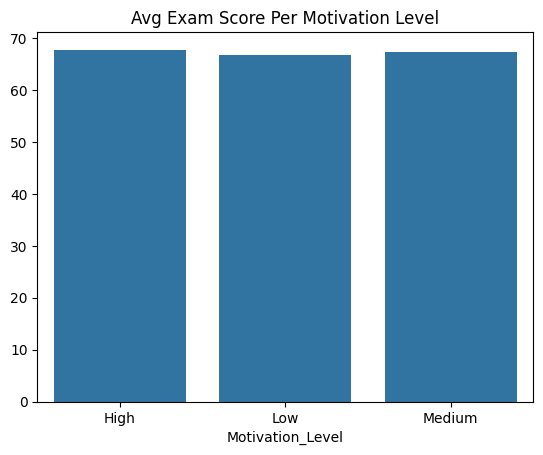

In [26]:
res = df.groupby('Motivation_Level')['Exam_Score'].mean()
x,y = res.index,res.values
sns.barplot(x=x,y=y)
plt.title('Avg Exam Score Per Motivation Level')
plt.show()

## 2- Which Gender has a higher average Exam_Score

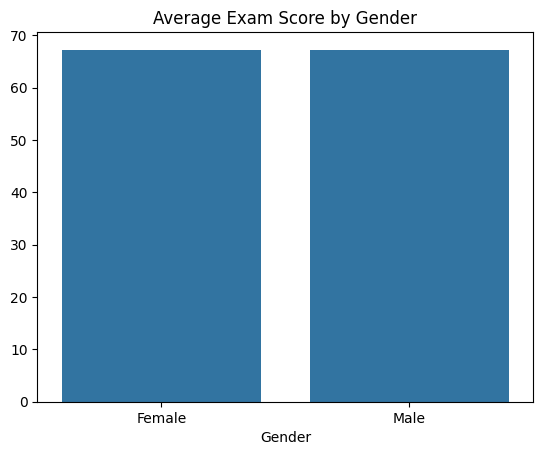

In [27]:
res = df.groupby('Gender')['Exam_Score'].mean()
sns.barplot(x=res.index, y=res.values)
plt.title('Average Exam Score by Gender')
plt.show()

## 3- Do students with Internet_Access score higher

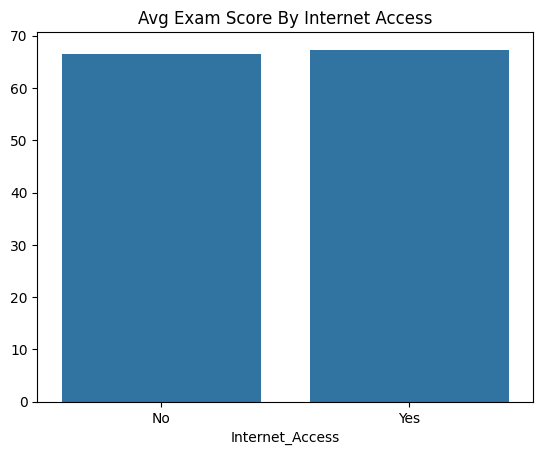

In [28]:
res = df.groupby('Internet_Access')['Exam_Score'].mean()
x, y = res.index, res.values
sns.barplot(x=x, y=y)
plt.title('Avg Exam Score By Internet Access')
plt.show()

## 4- Average Hours_Studied per Family_Income

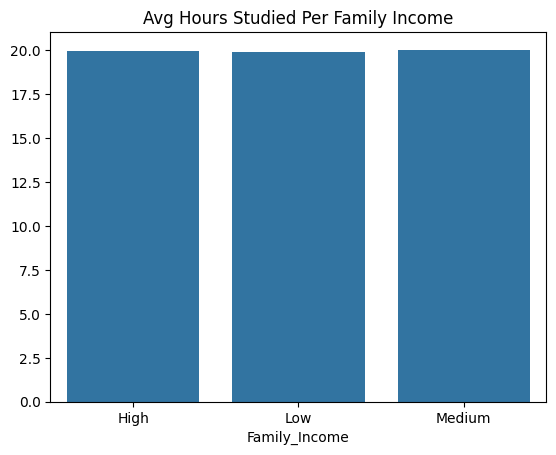

In [29]:
res = df.groupby('Family_Income')['Hours_Studied'].mean()
x, y = res.index, res.values
sns.barplot(x=x, y=y)
plt.title('Avg Hours Studied Per Family Income')
plt.show()

## 5- How Many Students with Learning_Disabilities and their avg score

                       count       mean
Learning_Disabilities                  
No                      6221  67.338370
Yes                      730  66.352055


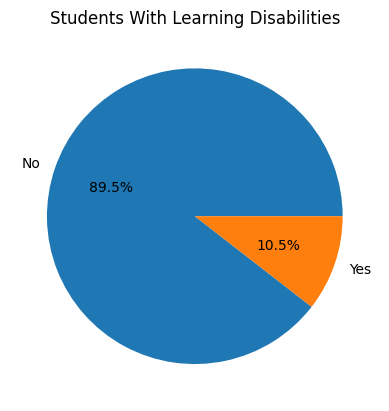

In [30]:
res = df.groupby('Learning_Disabilities')['Exam_Score'].agg(['count', 'mean'])
print(res)
sizes = df['Learning_Disabilities'].value_counts()
x, y = sizes.index, sizes.values
plt.pie(y, labels=x, autopct='%1.1f%%')
plt.title('Students With Learning Disabilities')
plt.show()

## 6-Public schools vs private schools distribution and average grades

School_Type
Private    67.292220
Public     67.209787
Name: Exam_Score, dtype: float64


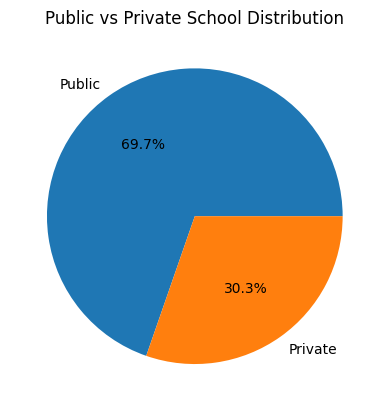

In [31]:
res = df.groupby('School_Type')['Exam_Score'].mean()
print(res)
sizes = df['School_Type'].value_counts()
x, y = sizes.index, sizes.values
plt.pie(y, labels=x, autopct='%1.1f%%')
plt.title('Public vs Private School Distribution')
plt.show()

## 7- What is the distribution of the exam marks

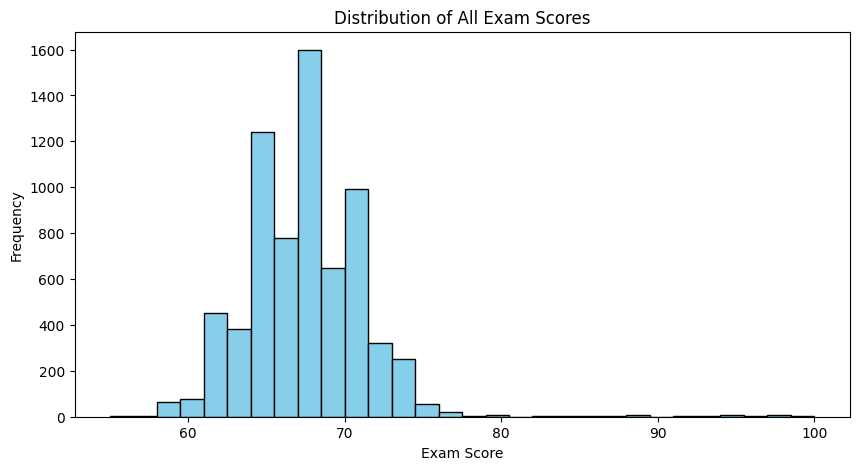

In [32]:
plt.figure(figsize=(10, 5))
plt.hist(df['Exam_Score'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of All Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')
plt.show()

## 8- Correlation between Hours_Studied, Attendance, Sleep_Hours and Exam_Score

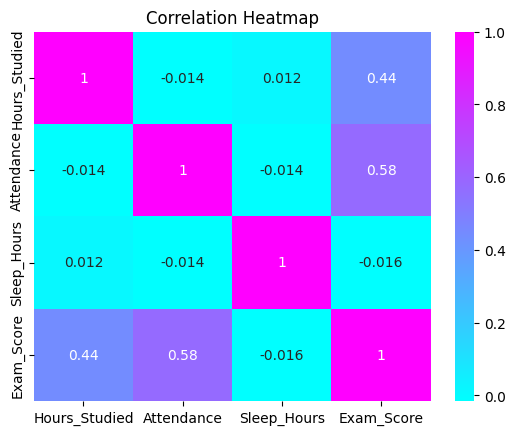

In [33]:
cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Exam_Score']
sns.heatmap(df[cols].corr(), annot=True, cmap='cool')
plt.title('Correlation Heatmap')
plt.show()

## 9- Tutoring_Sessions vs Exam_Score

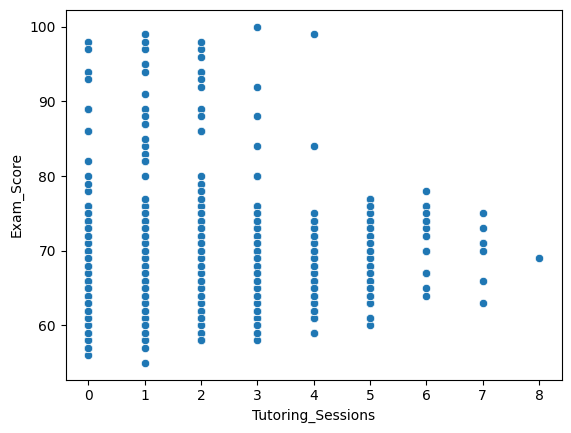

In [34]:
sns.scatterplot(x="Tutoring_Sessions",y="Exam_Score",data = df)
plt.show()

## 10- Does school and parents income affect score?

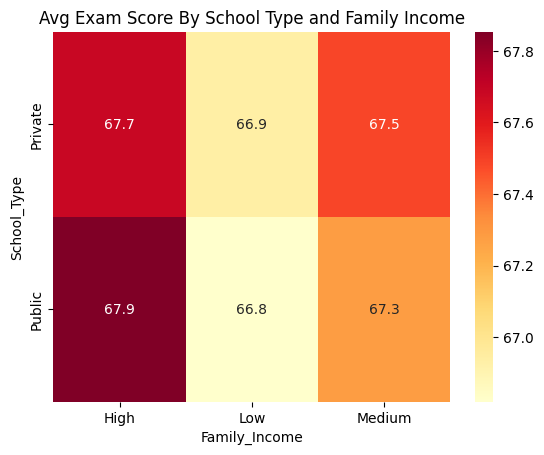

In [35]:
pivot = pd.pivot_table(df, index='School_Type', columns='Family_Income', values='Exam_Score', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Avg Exam Score By School Type and Family Income')
pivot = pivot[['Low', 'Medium', 'High']]
plt.show()

 ## 11- can "high effort" can overcome socioeconomic barriers.

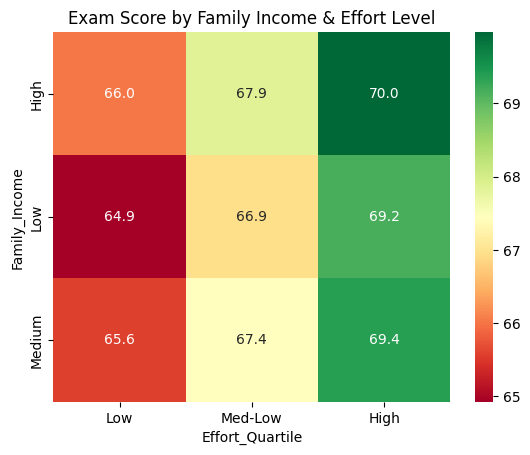

In [36]:
df['Effort_Score'] = df['Hours_Studied'] + (df['Tutoring_Sessions'] * 2)
df['Effort_Quartile'] = pd.qcut(df['Effort_Score'], 3, labels=['Low', 'Med-Low', 'High'])
res = df.groupby(['Family_Income', 'Effort_Quartile'])['Exam_Score'].mean().unstack()

sns.heatmap(res, annot=True, cmap='RdYlGn', fmt='.1f')
plt.title('Exam Score by Family Income & Effort Level')
plt.show()

## 12- Does studying more always lead to a better score

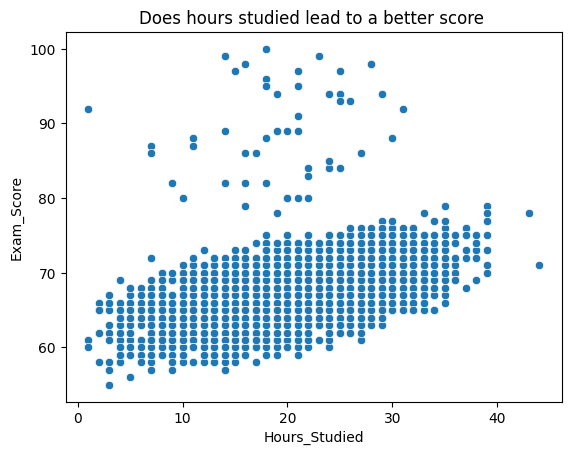

In [37]:
sns.scatterplot(x="Hours_Studied", y ='Exam_Score', data = df)
plt.title('Does hours studied lead to a better score ')
plt.show()

## 13- top 10% students vs bottom 10% students

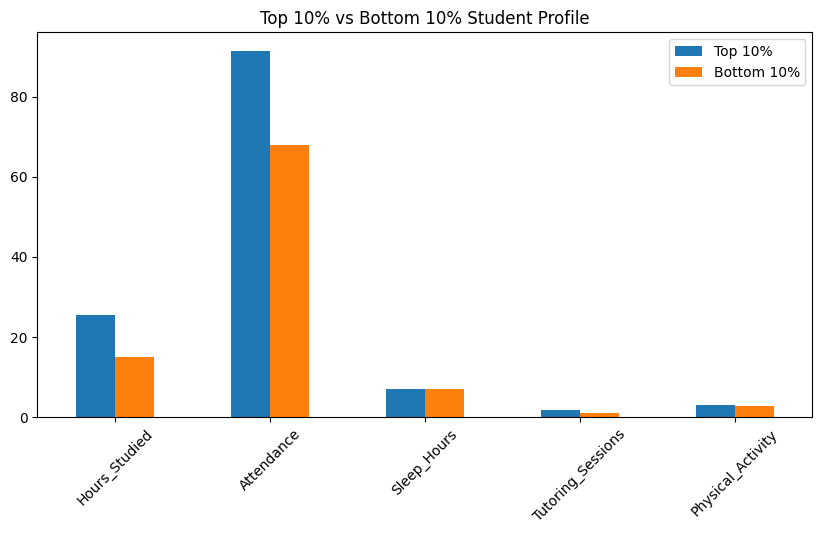

In [38]:
top = df[df['Exam_Score'] >= df['Exam_Score'].quantile(0.90)]
bottom = df[df['Exam_Score'] <= df['Exam_Score'].quantile(0.10)]

cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Tutoring_Sessions', 'Physical_Activity']
comparison = pd.DataFrame({
    'Top 10%': top[cols].mean(),
    'Bottom 10%': bottom[cols].mean()
})

comparison.plot(kind='bar', figsize=(10, 5))
plt.title('Top 10% vs Bottom 10% Student Profile')
plt.xticks(rotation=45)
plt.show()

## 14- What's the routine of the students with high attendance

In [39]:
df[df['Attendance'] > 90][['Exam_Score', 'Hours_Studied', 'Attendance']]


,Exam_Score,Hours_Studied,Attendance
2,67,24,98
4,67,19,92
8,67,17,94
9,67,23,98
11,67,17,97
...,...,...,...
7578,71,29,92
7616,68,25,93
7619,67,12,97
7627,73,32,93


In [40]:
df[df['Attendance'] > 90][['Exam_Score', 'Hours_Studied']].mean()

Exam_Score       70.108787
Hours_Studied    19.867902
dtype: float64

## 15-  What is the most common motivation level among top scorers (above 85)

In [41]:
df[df['Exam_Score'] > 85]['Motivation_Level'].value_counts()

Motivation_Level
Medium    18
High       9
Low        8
Name: count, dtype: int64